In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve, precision_recall_curve
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.datasets import load_wine
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score
from sklearn.cluster import SpectralClustering, AffinityPropagation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve, precision_recall_curve
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, Birch, SpectralClustering, AffinityPropagation, OPTICS
from sklearn.mixture import GaussianMixture
from hdbscan import HDBSCAN
from sklearn.ensemble import IsolationForest
from minisom import MiniSom
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler

from sklearn.base import clone
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

import warnings
from deap import base, creator, tools, algorithms
plt.rcParams['figure.dpi'] = 50
with warnings.catch_warnings():
    warnings.simplefilter("ignore")



In [2]:
# Load data
df_base = pd.read_csv('./cicids_2017_profiles_new.csv', header=0)
white_list=["172.16.0.1", #Firewall
            "192.168.10.3",#DNS+ DC Server
            "192.168.10.1"#GateWay
           
           ]

df_base = df_base[~df_base['ip_src'].isin(white_list)]

all_ips = df_base.iloc[:, 31]
#print("ISX 2014 Profile Count:", len(all_ips))
#print("ISX 2014 Raw Log Count: 14,502,784")
print("CIC-IDS 2017 Profile Count:", len(all_ips))
print("CIC-IDS 2017 Raw Log Count: 55,066,444")
kmeans_cluster_count = 3
df_base.isnull().values.any()
df_base.fillna(0, inplace=True)
df_base=df_base.loc[:, (df_base != 0).any(axis=0)]

my_data = df_base.drop(["ReqTime", "ip_src", "RowNo"], axis=1)

cluster_count=3

CIC-IDS 2017 Profile Count: 18484
CIC-IDS 2017 Raw Log Count: 55,066,444


In [3]:
all_ips=list(set(df_base["ip_src"]))
#private ips
infected_ips = [
"192.168.10.50",
"192.168.10.51",
"192.168.10.19",
"192.168.10.17",
"192.168.10.16",
"192.168.10.12",
"192.168.10.9",
"192.168.10.5",
"192.168.10.8",
"192.168.10.14",
"192.168.10.15",
"192.168.10.25"]
infected_ips = [itm for itm in infected_ips if itm in all_ips]
print("infected_ips:")
print(len(infected_ips))


infected_ips:
12


In [4]:
my_data.describe()

,P1_rph,P2_unique_dns_req,P3_domain_rph,P4_avg_rpm,P5_high_req,P6_mx,P7_ptr,P9_TDL,P10_SDL,P11_unique_ratio,...,P20_SSH_ratio,P21_MQTT_ratio,P22_TFTP_ratio,P23_NBNS_ratio,P24_TCP_ratio,P25_DCERPC_ratio,P26_ICMP_ratio,P27_DHCP_ratio,P28_UNIQUEDST_count,P29_DST_count
count,1.848400e+04,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,...,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,1.848400e+04
mean,2.591303e+03,6.362043,0.760874,1.305399,0.199794,0.095109,4.094893,3.530188,7.720353,0.001296,...,0.001020,0.000132,0.000245,0.000410,0.606584,0.000012,0.000012,0.000236,9.425124,2.591303e+03
std,4.287750e+04,52.943773,8.948998,10.831659,5.111171,7.099409,62.730565,26.219193,58.530851,0.134217,...,0.009026,0.008412,0.006493,0.006940,0.256210,0.000236,0.000236,0.005685,52.436811,4.287750e+04
min,1.010000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.010000e+02
25%,1.490000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.485565,0.000000,0.000000,0.000000,1.000000,1.490000e+02
50%,2.570000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.656863,0.000000,0.000000,0.000000,1.000000,2.570000e+02
75%,5.880000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.792093,0.000000,0.000000,0.000000,4.000000,5.880000e+02
max,2.611693e+06,1039.000000,482.000000,302.000000,596.000000,824.000000,2668.000000,415.000000,1039.000000,17.375000,...,0.389289,1.000000,0.344681,0.304225,1.000000,0.012723,0.012723,0.416887,977.000000,2.611693e+06


In [5]:
corr = my_data.corr()
#print(corr)


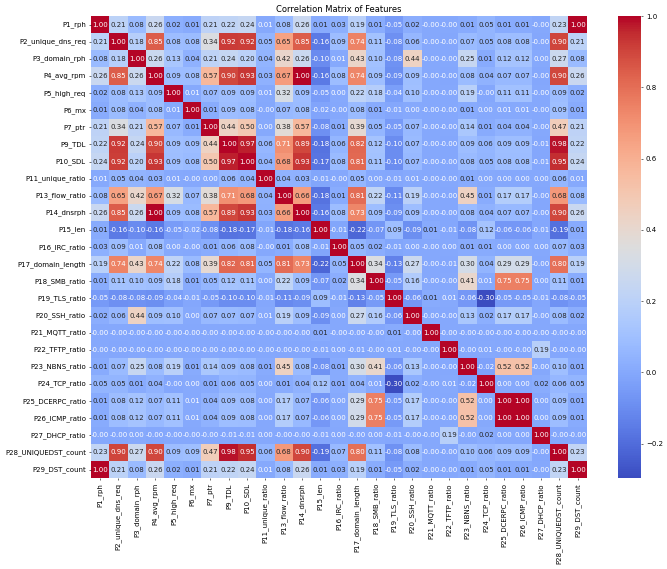

In [6]:

# Plot heatmap of the correlation matrix
plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Matrix of Features")
plt.show()

In [7]:
# Remove features with high correlation 
threshold = 0.9
upper_tri = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]
my_data = my_data.drop(to_drop, axis=1)
print("Removed Features:",to_drop)
cols=list(my_data)

Removed Features: ['P9_TDL', 'P10_SDL', 'P14_dnsrph', 'P26_ICMP_ratio', 'P28_UNIQUEDST_count', 'P29_DST_count']


In [8]:
my_data.describe()

,P1_rph,P2_unique_dns_req,P3_domain_rph,P4_avg_rpm,P5_high_req,P6_mx,P7_ptr,P11_unique_ratio,P13_flow_ratio,P15_len,...,P17_domain_length,P18_SMB_ratio,P19_TLS_ratio,P20_SSH_ratio,P21_MQTT_ratio,P22_TFTP_ratio,P23_NBNS_ratio,P24_TCP_ratio,P25_DCERPC_ratio,P27_DHCP_ratio
count,1.848400e+04,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,...,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000,18484.000000
mean,2.591303e+03,6.362043,0.760874,1.305399,0.199794,0.095109,4.094893,0.001296,0.002855,873.495707,...,0.557485,0.000095,0.278840,0.001020,0.000132,0.000245,0.000410,0.606584,0.000012,0.000236
std,4.287750e+04,52.943773,8.948998,10.831659,5.111171,7.099409,62.730565,0.134217,0.020713,572.608501,...,3.327055,0.001696,0.209072,0.009026,0.008412,0.006493,0.006940,0.256210,0.000236,0.005685
min,1.010000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.490000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,355.597652,...,0.000000,0.000000,0.106434,0.000000,0.000000,0.000000,0.000000,0.485565,0.000000,0.000000
50%,2.570000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,797.667930,...,0.000000,0.000000,0.267974,0.000000,0.000000,0.000000,0.000000,0.656863,0.000000,0.000000
75%,5.880000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1345.696861,...,0.000000,0.000000,0.437874,0.000000,0.000000,0.000000,0.000000,0.792093,0.000000,0.000000
max,2.611693e+06,1039.000000,482.000000,302.000000,596.000000,824.000000,2668.000000,17.375000,0.678977,3526.574884,...,31.500000,0.099379,1.000000,0.389289,1.000000,0.344681,0.304225,1.000000,0.012723,0.416887


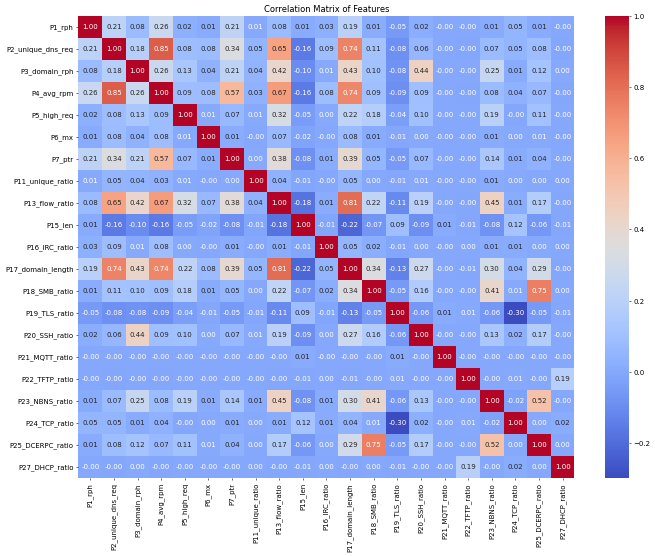

In [9]:
corr = my_data.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Matrix of Features")
plt.show()

In [10]:

# Inspect the dataframe
print(my_data.columns)
print(my_data.head())


Index(['P1_rph', 'P2_unique_dns_req', 'P3_domain_rph', 'P4_avg_rpm',
       'P5_high_req', 'P6_mx', 'P7_ptr', 'P11_unique_ratio', 'P13_flow_ratio',
       'P15_len', 'P16_IRC_ratio', 'P17_domain_length', 'P18_SMB_ratio',
       'P19_TLS_ratio', 'P20_SSH_ratio', 'P21_MQTT_ratio', 'P22_TFTP_ratio',
       'P23_NBNS_ratio', 'P24_TCP_ratio', 'P25_DCERPC_ratio',
       'P27_DHCP_ratio'],
      dtype='object')
   P1_rph  P2_unique_dns_req  P3_domain_rph  P4_avg_rpm  P5_high_req  P6_mx  \
0     524                  0              0           0            0      0   
1     547                  0              0           0            0      0   
2     544                  0              0           0            0      0   
3     433                  0              0           0            0      0   
4    2318                  0              0           0            0      0   

   P7_ptr  P11_unique_ratio  P13_flow_ratio      P15_len  ...  \
0       0               0.0             0.0  1884.12

In [11]:
# Data preprocessing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(my_data)
scaled_df = pd.DataFrame(X_scaled, columns=my_data.columns)


In [12]:
my_data.isnull().values.any()

False

In [13]:

my_data.head(2)

,P1_rph,P2_unique_dns_req,P3_domain_rph,P4_avg_rpm,P5_high_req,P6_mx,P7_ptr,P11_unique_ratio,P13_flow_ratio,P15_len,...,P17_domain_length,P18_SMB_ratio,P19_TLS_ratio,P20_SSH_ratio,P21_MQTT_ratio,P22_TFTP_ratio,P23_NBNS_ratio,P24_TCP_ratio,P25_DCERPC_ratio,P27_DHCP_ratio
0,524,0,0,0,0,0,0,0.0,0.0,1884.120229,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.980916,0.0,0.0
1,547,0,0,0,0,0,0,0.0,0.0,1877.811700,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


In [14]:
X=scaled_df.values


In [15]:
from sklearn.model_selection import GridSearchCV

pca = PCA(0.95)
X_pca = pca.fit_transform(X_scaled) 
reduced_X=pd.DataFrame(data=pca.fit_transform(X_pca))

reduced_X.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,-0.394946,-0.048227,2.203564,-0.419352,-0.304503,0.474671,-0.592012,0.059255,-0.136016,0.303020,0.634109,-0.656819,-0.025926,0.204972,-0.152511,-0.522563
1,-0.489134,0.107260,-0.539668,-0.089512,-0.117895,0.524795,-0.235957,-0.023719,-0.125738,0.221935,0.326886,-0.016356,0.044966,0.638784,-1.047312,-2.825840
2,-0.399557,-0.050237,2.249784,-0.431833,-0.309758,0.499664,-0.611916,0.062924,-0.140048,0.318601,0.656537,-0.683435,-0.026534,0.200280,-0.147119,-0.508095
3,-0.390919,-0.050628,2.246553,-0.421088,-0.306465,0.461370,-0.591554,0.059632,-0.134362,0.297676,0.631561,-0.661131,-0.027285,0.197224,-0.133561,-0.475644
4,-0.248185,-0.058693,1.978363,-0.236064,-0.239201,-0.112481,-0.225015,-0.004444,-0.045351,-0.036530,0.186290,-0.187799,-0.034532,0.171748,-0.010934,-0.127650


In [16]:
# component_df=pd.DataFrame(pca.components_,index=reduced_X.columns)
# # Heat map
# sns.pairplot(component_df)
# plt.suptitle('Pairplot of Principal Components', y=1.02)
# plt.show()

In [17]:
param_grids = {
    'KMeans': {'n_clusters': [2, 3, 4, 5, 6]},
    'AgglomerativeClustering': {'n_clusters': [2, 3, 4, 5, 6]},
    'DBSCAN': {'eps': [0.3, 0.5, 0.7], 'min_samples': [3, 5, 10]},
    'GaussianMixture': {'n_components': [2, 3, 4, 5, 6], 'covariance_type': ['full', 'tied', 'diag', 'spherical']},
    'Birch': {'n_clusters': [2, 3, 4, 5, 6]},
    'MeanShift': {'bandwidth': [1, 2, 3]},
    'SpectralClustering': {'n_clusters': [2, 3, 4, 5, 6], 'affinity': ['nearest_neighbors', 'rbf']}, #graph
    'AffinityPropagation': {'damping': [0.5, 0.6, 0.7, 0.8, 0.9]}, #graph
    'HDBSCAN': {'min_cluster_size': [5, 10, 15]},
    'OPTICS': {'min_samples': [5, 10, 15], 'xi': [0.01, 0.05, 0.1], 'min_cluster_size': [0.05, 0.1, 0.2]},
}

# Define clustering models
models = {
    'KMeans': KMeans(random_state=0),
    'AgglomerativeClustering': AgglomerativeClustering(),
    'DBSCAN': DBSCAN(),
    'GaussianMixture': GaussianMixture(random_state=0),
    'Birch': Birch(),
    'MeanShift': MeanShift(),
   # 'SpectralClustering': SpectralClustering(random_state=0),
   # 'AffinityPropagation': AffinityPropagation(),
    'HDBSCAN': HDBSCAN(),
    'OPTICS': OPTICS(),
}

In [18]:
import ipaddress
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix


def is_private_ip(ip):
    return True
    try:
        ip_obj = ipaddress.ip_address(ip)
        return ip_obj.is_private
    except ValueError:
        return False 

In [19]:
# Calculate ROC AUC for each model
def calculate_roc_auc(model, X, y_true):
  try:
    model.fit(X)
    if hasattr(model, 'labels_'):
        y_pred = model.labels_
    else:
        y_pred = model.predict(X)
    clusters = {}
    n = 0
    for item in y_pred:
        if item in clusters:
            clusters[item].append(df_base.iloc[n]['ip_src'])
        else:
            clusters[item] = [df_base.iloc[n]['ip_src']]
        
        n +=1
    normal_cluster=0
    predicted_labels=[]
    
    for item in clusters:
        if(len(clusters[item])>len(clusters[normal_cluster])):
            normal_cluster=item
        
        # print ("Cluster ", item,' Count: ',len(clusters[item]),' DCCount: ',len(list(set(clusters[item]))))
        # print("Count: ",len(list(set(clusters[item]))))
     #   print("Data: \n",(list(set(clusters[item]))),"\n\n")
        if(item>0):
            for i in clusters[item]:
                 predicted_labels.append(i)
    # print("Normal Cluster index: ",normal_cluster)
    # برچسب‌های خوشه (تخمین زده شده)
    bad_items=[]
    for item in clusters:
        if(item!=normal_cluster):
            for bd_item in list(set(clusters[item])):
                bad_items.append(bd_item)



      
    y_true = []
    
    y_scores = []
    FP = []
    FN = []
    TP = []
    TN = []
    
    
    detected_ips = bad_items
    
    
    for ip in all_ips:
      if is_private_ip(ip):
        if ip in infected_ips :
            y_true.append(1)  # آلوده
        else:
            y_true.append(0)  # عادی
    
        
        if ip in detected_ips :
            #print(ip)
            y_scores.append(1)  # آلوده
        else:
            y_scores.append(0)  # عادی
    
        if not(ip in infected_ips) and (ip in detected_ips) :
            FP.append(ip) 
            #print("over detected (FP):",str(ip))
        if (ip in infected_ips) and not(ip in detected_ips)  :
            FN.append(ip) 
           # print("not detected (FN):",str(ip))
        if  (ip in infected_ips) and (ip in detected_ips):
            TP.append(ip) 
        if not(ip in infected_ips) and not(ip in detected_ips) :
            TN.append(ip) 
      else:
        TN.append(ip)
        y_true.append(0)  # عادی
        y_scores.append(0)  # عادی
    y_scores=np.array(y_scores)
    y_true=np.array(y_true)
    print("####Model::::",model)
    print("Infected:" ,len(infected_ips))
    print("Detected:" ,len(bad_items))
    print("FP Count:" ,len(FP))
    print("FN Count:" ,len(FN))
    print("TP Count:" ,len(TP))
    print("TN Count:" ,len(TN))
    print("Distinct IP Count:" ,len(all_ips))
    auroc = roc_auc_score(np.array(y_true),np.array( y_scores))
    print("TP Count:" ,len(TP))
    print("FP Count:" ,len(FP))
    print("@@@@AUROC: ", round(auroc,4))
    print("---------------------------------------")
    return auroc, y_scores, y_true,y_pred,FP
  except:
      return 0, 0, 0,0,0


In [20]:
print("Models Count: ",str(len(models)))

Models Count:  8


####Model:::: KMeans(n_clusters=2, random_state=0)
Infected: 12
Detected: 12
FP Count: 0
FN Count: 0
TP Count: 12
TN Count: 5587
Distinct IP Count: 5599
TP Count: 12
FP Count: 0
@@@@AUROC:  1.0
---------------------------------------
####Model:::: KMeans(n_clusters=3, random_state=0)
Infected: 12
Detected: 27
FP Count: 3
FN Count: 0
TP Count: 12
TN Count: 5584
Distinct IP Count: 5599
TP Count: 12
FP Count: 3
@@@@AUROC:  0.9997
---------------------------------------
####Model:::: KMeans(n_clusters=4, random_state=0)
Infected: 12
Detected: 3031
FP Count: 2999
FN Count: 0
TP Count: 12
TN Count: 2588
Distinct IP Count: 5599
TP Count: 12
FP Count: 2999
@@@@AUROC:  0.7316
---------------------------------------
####Model:::: KMeans(n_clusters=5, random_state=0)
Infected: 12
Detected: 4348
FP Count: 3783
FN Count: 0
TP Count: 12
TN Count: 1804
Distinct IP Count: 5599
TP Count: 12
FP Count: 3783
@@@@AUROC:  0.6614
---------------------------------------
####Model:::: KMeans(n_clusters=6, rand

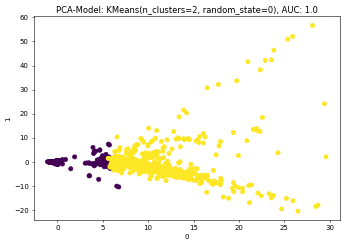

####Model:::: AgglomerativeClustering()
Infected: 12
Detected: 15
FP Count: 3
FN Count: 0
TP Count: 12
TN Count: 5584
Distinct IP Count: 5599
TP Count: 12
FP Count: 3
@@@@AUROC:  0.9997
---------------------------------------
####Model:::: AgglomerativeClustering(n_clusters=3)
Infected: 12
Detected: 21
FP Count: 3
FN Count: 0
TP Count: 12
TN Count: 5584
Distinct IP Count: 5599
TP Count: 12
FP Count: 3
@@@@AUROC:  0.9997
---------------------------------------
####Model:::: AgglomerativeClustering(n_clusters=4)
Infected: 12
Detected: 22
FP Count: 3
FN Count: 0
TP Count: 12
TN Count: 5584
Distinct IP Count: 5599
TP Count: 12
FP Count: 3
@@@@AUROC:  0.9997
---------------------------------------
####Model:::: AgglomerativeClustering(n_clusters=5)
Infected: 12
Detected: 23
FP Count: 3
FN Count: 0
TP Count: 12
TN Count: 5584
Distinct IP Count: 5599
TP Count: 12
FP Count: 3
@@@@AUROC:  0.9997
---------------------------------------
####Model:::: AgglomerativeClustering(n_clusters=6)
Infected

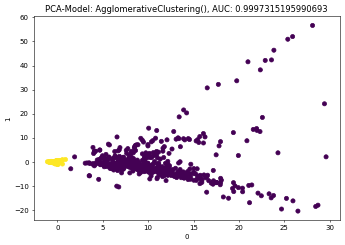

####Model:::: DBSCAN(eps=0.3, min_samples=3)
Infected: 12
Detected: 535
FP Count: 498
FN Count: 0
TP Count: 12
TN Count: 5089
Distinct IP Count: 5599
TP Count: 12
FP Count: 498
@@@@AUROC:  0.9554
---------------------------------------
####Model:::: DBSCAN(eps=0.3)
Infected: 12
Detected: 590
FP Count: 556
FN Count: 0
TP Count: 12
TN Count: 5031
Distinct IP Count: 5599
TP Count: 12
FP Count: 556
@@@@AUROC:  0.9502
---------------------------------------
####Model:::: DBSCAN(eps=0.3, min_samples=10)
Infected: 12
Detected: 1816
FP Count: 1592
FN Count: 0
TP Count: 12
TN Count: 3995
Distinct IP Count: 5599
TP Count: 12
FP Count: 1592
@@@@AUROC:  0.8575
---------------------------------------
####Model:::: DBSCAN(min_samples=3)
Infected: 12
Detected: 235
FP Count: 204
FN Count: 0
TP Count: 12
TN Count: 5383
Distinct IP Count: 5599
TP Count: 12
FP Count: 204
@@@@AUROC:  0.9817
---------------------------------------
####Model:::: DBSCAN()
Infected: 12
Detected: 238
FP Count: 224
FN Count: 0


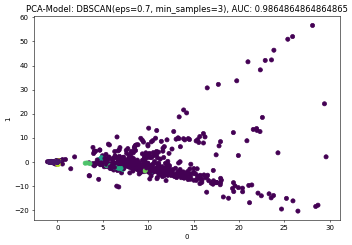

####Model:::: GaussianMixture(n_components=2, random_state=0)
Infected: 12
Detected: 79
FP Count: 67
FN Count: 0
TP Count: 12
TN Count: 5520
Distinct IP Count: 5599
TP Count: 12
FP Count: 67
@@@@AUROC:  0.994
---------------------------------------
####Model:::: GaussianMixture(n_components=3, random_state=0)
Infected: 12
Detected: 112
FP Count: 88
FN Count: 0
TP Count: 12
TN Count: 5499
Distinct IP Count: 5599
TP Count: 12
FP Count: 88
@@@@AUROC:  0.9921
---------------------------------------
####Model:::: GaussianMixture(n_components=4, random_state=0)
Infected: 12
Detected: 1579
FP Count: 1542
FN Count: 0
TP Count: 12
TN Count: 4045
Distinct IP Count: 5599
TP Count: 12
FP Count: 1542
@@@@AUROC:  0.862
---------------------------------------
####Model:::: GaussianMixture(n_components=5, random_state=0)
Infected: 12
Detected: 1073
FP Count: 980
FN Count: 0
TP Count: 12
TN Count: 4607
Distinct IP Count: 5599
TP Count: 12
FP Count: 980
@@@@AUROC:  0.9123
-------------------------------

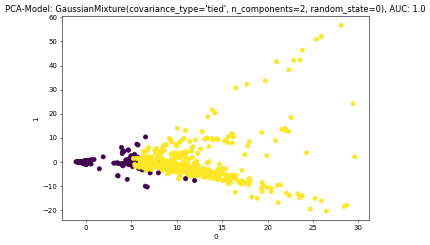

####Model:::: Birch(n_clusters=2)
Infected: 12
Detected: 6
FP Count: 0
FN Count: 6
TP Count: 6
TN Count: 5587
Distinct IP Count: 5599
TP Count: 6
FP Count: 0
@@@@AUROC:  0.75
---------------------------------------
####Model:::: Birch()
Infected: 12
Detected: 21
FP Count: 3
FN Count: 0
TP Count: 12
TN Count: 5584
Distinct IP Count: 5599
TP Count: 12
FP Count: 3
@@@@AUROC:  0.9997
---------------------------------------
####Model:::: Birch(n_clusters=4)
Infected: 12
Detected: 22
FP Count: 3
FN Count: 0
TP Count: 12
TN Count: 5584
Distinct IP Count: 5599
TP Count: 12
FP Count: 3
@@@@AUROC:  0.9997
---------------------------------------
####Model:::: Birch(n_clusters=5)
Infected: 12
Detected: 23
FP Count: 3
FN Count: 0
TP Count: 12
TN Count: 5584
Distinct IP Count: 5599
TP Count: 12
FP Count: 3
@@@@AUROC:  0.9997
---------------------------------------
####Model:::: Birch(n_clusters=6)
Infected: 12
Detected: 25
FP Count: 3
FN Count: 0
TP Count: 12
TN Count: 5584
Distinct IP Count: 5599
T

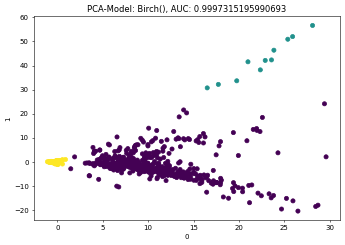

In [ ]:
# With  PCA
roc_auc_scores = {}
best_models = {}
algorithms_execution_time=[]
algorithms_cpu_usage=[]
algorithms_mem_usage=[]

import time
import psutil
for name, model in models.items():

    best_auc = 0
    best_model = None
    best_params = None
    best_y_pred = None
    best_FP = None
    best_execution_time = None
    best_cpu_usage = None
    best_mem = None
    
    for params in ParameterGrid(param_grids[name]):

        cpu_start = psutil.cpu_percent()
        mem_start = psutil.virtual_memory().used
        start_time = time.time()

        model.set_params(**params)
        
        auroc, y_scores, y_true,y_pred,FP = calculate_roc_auc(model, X_pca, my_data[cols])

        end_time=time.time()
        execution_time = end_time-start_time
        cpu_end = psutil.cpu_percent()
        mem_end = psutil.virtual_memory().used  
        mem_usage=mem_end - mem_start
        cpu_usage=cpu_end - cpu_start
        if auroc > best_auc:
            best_auc = auroc
            best_model = clone(model)
            best_params = params
            best_y_pred = y_pred
            best_y_true = y_true
            best_y_scores= y_scores
            best_FP=FP
            best_execution_time=execution_time
            best_cpu_usage = cpu_usage
        
            best_mem = mem_usage
            
    algorithms_execution_time.append({"Algorithm":str(type(model).__name__),"Time":best_execution_time})
    algorithms_cpu_usage.append({"Algorithm":str(type(model).__name__),"CPU":best_cpu_usage})
    algorithms_mem_usage.append({"Algorithm":str(type(model).__name__),"Memory":best_mem})
    best_models[name] = {"model":best_model,
                         "auroc":best_auc,
                         "params":best_params,
                         "y_pred":best_y_pred,
                         "y_true":best_y_true,
                         "scores":best_y_scores,
                         "FP":FP
                            }
    roc_auc_scores[name] = best_auc


    
    print(f"{name} best_mem: {best_params} Bytes: {best_mem}")
    print(f"{name} best_cpu_usage: {best_params} %: {best_cpu_usage}")
    print(f"{name} best_execution_time: {best_params} Secs: {best_execution_time}")
    print(f"{name} Best Params: {best_execution_time} AUROC: {best_execution_time}")
    print(f"{name} FP: ",best_FP)
    plt.figure(figsize=(7,5))
 
    # Scatter plot
    plt.scatter(reduced_X[0],reduced_X[1],c=best_y_pred)
    plt.xlabel(0)
    plt.ylabel(1)
    plt.title("PCA-Model: "+str(best_model)+", AUC: "+str(best_auc))
    plt.tight_layout()
    plt.show()




In [ ]:

# time - algorithm computational cost
df_algorithms_execution_time = pd.DataFrame(algorithms_execution_time)

# Plotting
plt.figure(figsize=(20, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

plt.bar(df_algorithms_execution_time['Algorithm'], df_algorithms_execution_time['Time'], color=colors)

plt.grid(axis='y', linestyle='--', alpha=0.5)
for i in range(len(df_algorithms_execution_time['Algorithm'])):
        plt.text(i,round(df_algorithms_execution_time['Time'][i],4),round(df_algorithms_execution_time['Time'][i],4))
plt.title('Execution Time of Algorithms')
plt.xlabel('Algorithm')
plt.ylabel('Execution Time')
plt.legend(  loc ='best')

plt.show()



In [ ]:
print("Execution time comparation table of all algorithms:")

print(df_algorithms_execution_time)

In [ ]:

# memory - algorithm computational cost
df_algorithms_mem_usage = pd.DataFrame(algorithms_mem_usage)

# Plotting
plt.figure(figsize=(20, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

plt.bar(df_algorithms_mem_usage['Algorithm'], df_algorithms_mem_usage['Memory'], color=colors)

plt.grid(axis='y', linestyle='--', alpha=0.5)
for i in range(len(df_algorithms_mem_usage['Algorithm'])):
        plt.text(i,round(df_algorithms_mem_usage['Memory'][i],4),df_algorithms_mem_usage['Memory'][i])
plt.title('Memory Usage of Algorithms')
plt.xlabel('Algorithm')
plt.ylabel('Memory Usage (Bytes)')
plt.legend(  loc ='best')

plt.show()



In [ ]:
print("Memory Usage comparation table of all algorithms:")

print(df_algorithms_mem_usage)

In [ ]:

# cpu - algorithm computational cost
df_algorithms_cpu_usage = pd.DataFrame(algorithms_cpu_usage)

# Plotting
plt.figure(figsize=(20, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

plt.bar(df_algorithms_cpu_usage['Algorithm'], df_algorithms_cpu_usage['CPU'], color=colors)

plt.grid(axis='y', linestyle='--', alpha=0.5)
for i in range(len(df_algorithms_cpu_usage['Algorithm'])):
        plt.text(i,round(df_algorithms_cpu_usage['CPU'][i],4),df_algorithms_cpu_usage['CPU'][i])
plt.title('CPU Usage of Algorithms')
plt.xlabel('Algorithm')
plt.ylabel('CPU Usage (%)')
plt.legend(  loc ='best')

plt.show()



In [ ]:
print("CPU Usage comparation table of all algorithms:")
print(df_algorithms_cpu_usage)

In [ ]:
roc_auc_table = pd.DataFrame.from_dict(roc_auc_scores, orient='index', columns=['ROAUC'])
print("ROC_AUC omparation table of all algorithms:")
print(roc_auc_table)


# Plotting
plt.figure(figsize=(20, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

plt.bar(roc_auc_table.index,roc_auc_table['ROAUC'], color=colors)

plt.grid(axis='y', linestyle='--', alpha=0.5)
for i in range(len(roc_auc_table.index)):
        plt.text( i,round(roc_auc_table['ROAUC'][i],8)-0.05,str(round(roc_auc_table['ROAUC'][i],6)*100)+'%')
plt.title('roc auc OF Algorithms')
plt.xlabel('Algorithm')
plt.ylabel('Score')
 

plt.show()

In [ ]:

# Plot ROC curve and confusion matrix for the best model
best_model_name = roc_auc_table['ROAUC'].idxmax()
best_model = models[best_model_name]

print("Best Model is:",str(best_model))

In [ ]:
# Receiver Operating Characteristic (ROC) Curve

plt.figure(figsize=(10, 6))
for name in best_models:
    val=best_models[name]
    model=val['model']
    y_scores=val['scores']
    y_pred=val['y_pred']
    y_true=val['y_true']
    auroc=val['auroc']
    #auroc, y_scores, y_true,y_pred = calculate_roc_auc(model, X_pca, df_base[cols])
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    plt.plot(fpr, tpr, label=str(model)+", AUROC: "+str(round(auroc,5)))
plt.plot([0, 1], [0, 1], 'k--', label='Random chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='best')
plt.grid()
plt.show()


In [ ]:

plt.figure(figsize=(8, 6))
# Plot confusion matrix
#for name in best_models:
val=best_models[best_model_name]
model=val['model']
y_scores=val['scores']
y_pred=val['y_pred']
y_true=val['y_true']
auroc=val['auroc']
# Plot ROC Curve
threshold = 0.5
y_pred_binary = (y_scores >= threshold).astype(int)
cm = confusion_matrix(y_true, y_pred_binary)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for ' + str(model)+", AUC: "+ str(round(auroc,5)))
plt.show()
